<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Zadanie_3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

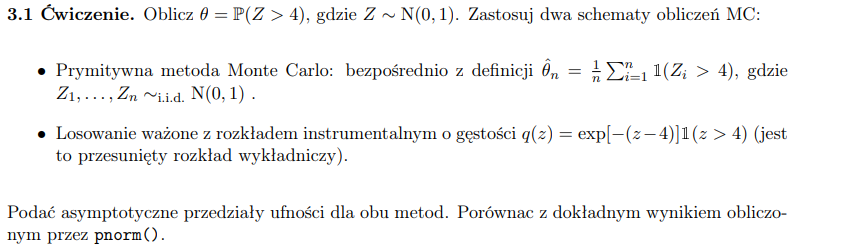

### Theoretical result
---

Of course, the theoretical value of $\theta$ equals:

$$
\theta = \mathbb{P}(Z > 1) =  1 - \Phi(4) \approx 3.167 \times 10^{-5}
$$

### Simulations
---

#### Crude Monte Carlo
---

In this case, we will calculate the estimator directly from definition:

$$\hat{\theta}_{CMC} = \frac{1}{n} \sum_{i=1}^n \mathbf{1}(Z_i > 4)$$

In [3]:
import numpy as np
import scipy.stats as stats

In [4]:
N = 100_000_000

# for further confidence interval
alpha = 0.05
z_alpha = stats.norm.ppf(1 - alpha/2)

# theoretical result
theta_theory = stats.norm.sf(4)

# sampling
Z = np.random.randn(N)

# indicator function
Y_cmc = (Z > 4).astype(float)

# theta estimation
theta_cmc = np.mean(Y_cmc)

# obtaining confidence interval
s_cmc = np.std(Y_cmc, ddof=1)
margin_cmc = z_alpha * s_cmc / np.sqrt(N)
ci_cmc = (theta_cmc - margin_cmc, theta_cmc + margin_cmc)

# results
print(f"Theoretical result: {theta_theory:.8f}")
print(f"CMC Estimator: {theta_cmc:.8f}")
print(f"CMC 95% Confidence interval: [{ci_cmc[0]:.8f}, {ci_cmc[1]:.8f}]")
print(f"CMC STD: {s_cmc:.8f}")

Theoretical result: 0.00003167
CMC Estimator: 0.00003278
CMC 95% Confidence interval: [0.00003166, 0.00003390]
CMC STD: 0.00572529


#### Importance Sampling
---

To make our sampling more efficient, we will draw observations from distribution defined only on set {$Z > 4$}. To achieve this, we will use shifted exponential distribution $q(x) = \exp(-(x-4)) \mathbb{1}_{(x > 4)}$. Then, we will compute the weights of sampled observations:
$$w(x) = \frac{p(x)}{q(x)},$$
where $p(x) = \frac{1}{\sqrt{2\pi}}e^{-x^2/2}$.

Therefore, our estimator can be described by the following formula:

$$\hat{\theta}_{IS} = \frac{1}{n} \sum_{i=1}^n \mathbb{1}_{(X_i > 4)} \cdot w(X_i) = \frac{1}{n} \sum_{i=1}^n w(X_i)$$

In [5]:
# sampling from exponential
X = 4 + np.random.exponential(scale=1, size=N)

# densities
p_x = (1 / np.sqrt(2 * np.pi)) * np.exp(-X**2 / 2)
q_x = np.exp(-(X-4))

w = p_x / q_x

# calcuating theta
theta_is = np.mean(w)

# obtaining confidence interval
s_is = np.std(w, ddof=1)
margin_is = z_alpha * s_is / np.sqrt(N)
ci_is = (theta_is - margin_is, theta_is + margin_is)

# results
print(f"Theoretical result: {theta_theory:.8f}")
print(f"CMC Estimator: {theta_is:.8f}")
print(f"CMC 95% Confidence interval: [{ci_is[0]:.8f}, {ci_is[1]:.8f}]")
print(f"CMC STD: {s_is:.8f}")

Theoretical result: 0.00003167
CMC Estimator: 0.00003167
CMC 95% Confidence interval: [0.00003166, 0.00003168]
CMC STD: 0.00003824


| Method | Estimator ($\hat{\theta}$) | 95% Confidence Interval | STD |
| :--- | :--- | :--- | :--- |
| **Theoretical result** | $0.00003167$ | - | - |
| **Crude Monte Carlo (CMC)** | $0.00003278$ | $[0.00003166, 0.00003390]$ | $0.00572529$ |
| **Importance Sampling (IS)** | $0.00003167$ | $[0.00003166, 0.00003168]$ | $0.00003824$ |

In [9]:
2*0.00572529/np.sqrt(N)

np.float64(1.145058e-06)

In [10]:
2*0.00572529/np.sqrt(N)/0.00003278

np.float64(0.03493160463697376)